In [1]:
import warnings
import time

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

from scipy.stats import norm, t, probplot
from scipy.special import gamma

# import thetaflow as thf
import modelnn2 as thf

2026-03-20 15:52:45.184839: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774032767.665934   21304 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3235 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/natan/codes/thetaflow_method_paper/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1774032767.698189   21304 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3235 MB memory:  -> device: 0, name: NVIDIA GeForc

In [2]:
# Count DSeq2 transformed matrix passed to the vsd in R
df = pd.read_csv("tcga_brca_count_data.csv")

print("Data dimensions: {}".format(df.shape))
df.head()

Data dimensions: (1094, 28394)


,time,delta,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,...,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288610.1,ENSG00000288611.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288663.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
0,652,0,9.236898,4.058348,10.964864,10.513271,8.862942,10.466286,11.631919,10.977731,...,4.332030,3.064062,4.058348,3.645597,5.313244,4.205053,6.229222,8.733492,4.444878,5.964324
1,1246,0,10.223195,5.281296,12.347547,10.076926,9.089810,8.651819,10.387053,12.466915,...,4.224119,3.971985,3.064062,3.593961,6.253292,3.809357,4.665666,7.980932,3.809357,5.908364
2,90,0,10.449917,4.484088,10.929133,10.244865,8.197153,7.820926,11.941674,11.399724,...,4.408410,4.484088,3.064062,4.140584,4.031214,3.064062,4.238209,8.172959,3.064062,5.537024
3,1471,0,10.943582,4.280462,10.949728,10.733436,8.308763,9.013656,11.545420,11.056104,...,4.606796,4.066634,3.779970,3.064062,4.859536,3.064062,5.846777,8.365070,3.779970,6.262540
4,172,1,9.740298,4.469670,11.298822,10.700813,8.708184,7.809997,11.841186,11.968232,...,3.549063,3.064062,3.064062,3.896475,5.939797,5.893332,4.783704,9.547732,4.226009,5.662420


In [3]:
# Count DSeq2 transformed matrix passed to the log(x + 1) function
df_log = pd.read_csv("tcga_brca_count_data_coxnnet.csv")

print("Data dimensions: {}".format(df_log.shape))
df_log.head()

Data dimensions: (1094, 28394)


,time,delta,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,...,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288610.1,ENSG00000288611.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288663.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
0,652,0,6.056784,1.386294,7.272398,6.956545,5.789960,6.923629,7.737616,7.281386,...,1.791759,0.000000,1.386294,0.693147,2.944439,1.609438,3.784190,5.697093,1.945910,3.555348
1,1246,0,6.941190,3.091042,8.423761,6.838405,6.139885,5.826000,7.056175,8.506739,...,1.791759,1.386294,0.000000,0.693147,3.988984,1.098612,2.397895,5.337538,1.098612,3.688879
2,90,0,7.257003,2.302585,7.592366,7.113142,5.652489,5.375278,8.298291,7.920810,...,2.197225,2.302585,0.000000,1.791759,1.609438,0.000000,1.945910,5.634790,0.000000,3.496508
3,1471,0,6.835185,1.386294,6.839476,6.688355,4.969813,5.476464,7.254885,6.913737,...,1.791759,1.098612,0.693147,0.000000,2.079442,0.000000,3.044522,5.010635,0.693147,3.401197
4,172,1,6.779922,2.302585,7.872455,7.454720,6.045005,5.389072,8.250359,8.338784,...,0.693147,0.000000,0.000000,1.386294,3.891820,3.850148,2.708050,6.643790,1.945910,3.637586


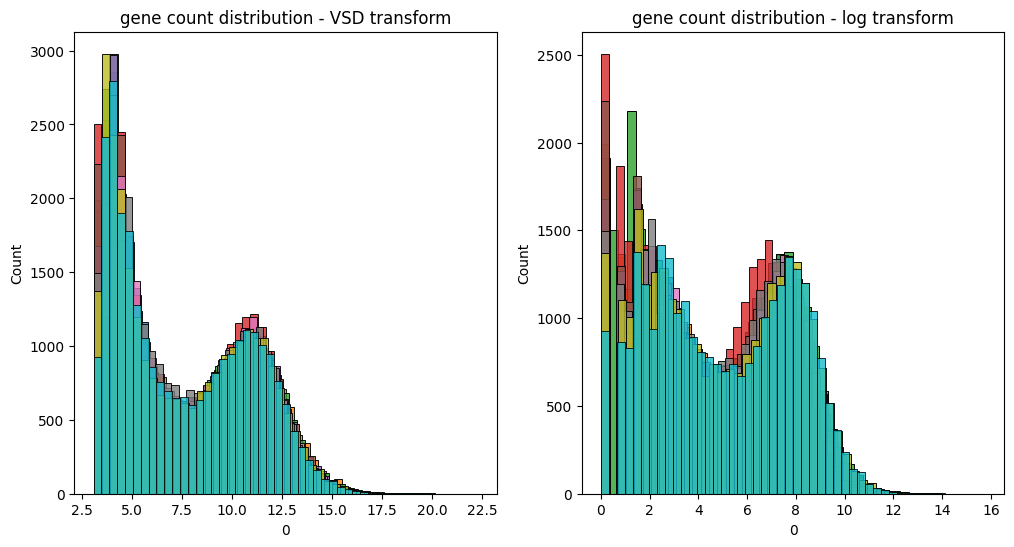

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

X = df.iloc[:,2:]
X_log = df_log.iloc[:,2:]

for i in range(10):
    sns.histplot(X.iloc[i, :], ax = ax[0], alpha = 0.8)
    sns.histplot(X_log.iloc[i, :], ax = ax[1], alpha = 0.8)

ax[0].set_title("gene count distribution - VSD transform")
ax[1].set_title("gene count distribution - log transform")
plt.show()

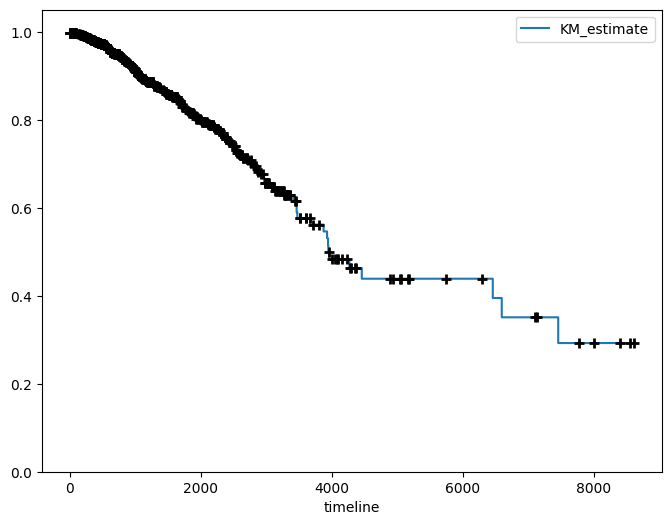

In [5]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df["time"], df["delta"])
km.plot(ax = ax, ci_show = False, show_censors = True, censor_styles={
    'ms': 7,      # marker size
    'marker': '+', # marker shape
    'mew': 2,       # marker edge width
    'markeredgecolor': 'black',
    'zorder': 5
})

ax.set_ylim(0,1.05)

plt.show()

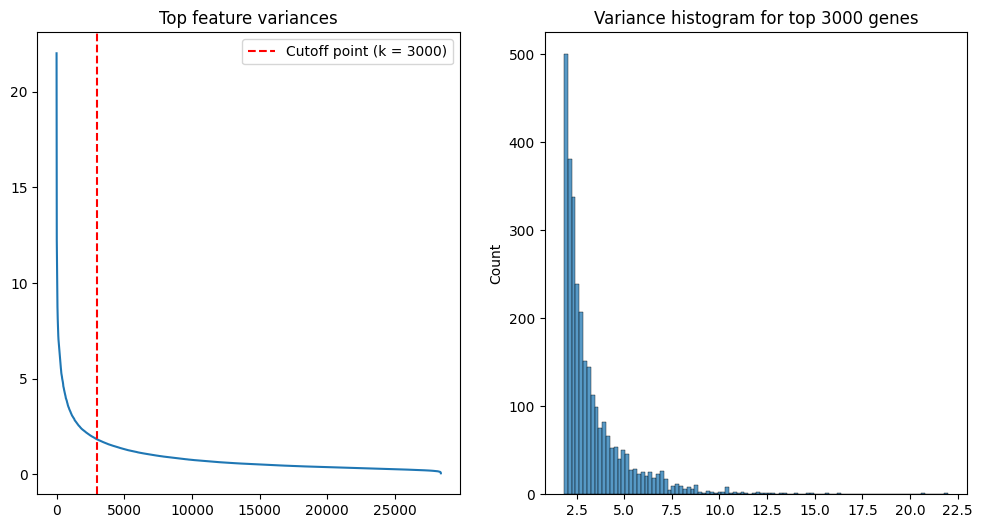

In [6]:
X = df.iloc[:,2:]
X_variances = np.var(X, ddof = 1, axis = 0)
# Sort the gene variances from greatest to smallest
i_sort = np.argsort( -X_variances )

X_variances_sort = X_variances.iloc[i_sort]
X_sort = X.iloc[:, i_sort]

k_genes = 3000
X_filtered = X.iloc[:, i_sort[:k_genes] ]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

ax[0].plot(np.arange(X_sort.shape[1]), X_variances_sort )
ax[0].axvline(k_genes, linestyle = "dashed", color = "red", label = "Cutoff point (k = {})".format(k_genes))
ax[0].set_title("Top feature variances")
ax[0].legend()

sns.histplot(X_variances_sort[:k_genes], ax = ax[1], bins = 100)
ax[1].set_title("Variance histogram for top 3000 genes")

plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

# X = X.iloc[:, i_sort[:3000] ].to_numpy()

# Standardize X so every feature has mean=0 and variance=1
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Keep X to be as it is for now. Uncomment code above to apply rescaling
X_scaled = tf.cast(X, dtype = tf.float32)

# y = tf.cast( df.iloc[:,0].to_numpy()/365, dtype = tf.float32 )
y = df.iloc[:,0].to_numpy()/365
# delta = tf.cast( df.iloc[:,1].to_numpy(), dtype = tf.float32 )
delta = df.iloc[:,1].to_numpy()
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(delta), 1), dtype = tf.float32)]

# Removing very early observations
y = y[df["time"] > 1]
delta = delta[df["time"] > 1]
X_scaled = tf.gather(X_scaled, np.where(df["time"] > 1)[0])
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(delta), 1), dtype = tf.float32)]

In our previous notebook, we ran into many problems regarding the high dimensionality of the genomic expression dataset, with around 28400 columns to only 1094 patients. That problem, combined with their survival times and censorship information, leads to a massive problem of complete separation. Given the huge dimensionality of our model, individuals can get completely separated with respect to their lifetimes and their variable attributes. Therefore, the model looses its ability to restrict boundaries to its predictions, since it has too many degrees of freedom, i.e. it can grow in an arbitrary dimension to cover the behaviour of a single patient.

What happens is essentially an overfitting caused by very high data dimensionality. To fix that, we tried implementing regularizers to the model, however, they were not able to solve the problem. In fact, while regularizers may allow a good model generalization, they require a tedious and difficult process of fine tuning their hyperparameters to perfection. A bad tuned hyperparameter may lead to completely different results.

Here, we start by filtering only the most expressive genes in the dataset first, by a simple variance check. After that, we will have a much smaller (but still of high dimensionality - $p \gg n$) dataset. Hopefully, the model will be able to generalize its results better in that scenario. We also hope that by doing that, training the hyperparameters for the associated regularizers will be easier.

In [8]:
def softplus(x):
    # Softplus guarantees positive output without a hard upper ceiling
    # It grows linearly, so gradients never vanish, allowing L2 to work
    return tf.math.softplus(x) + 1.0e-7

def softplus_inv(x):
    return tf.math.log(tf.math.exp(x - 1.0e-7) - 1.0)

# promotion_cure_parameters = {
#     "theta": {"link": softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": 3.0},
#     "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0}, # scale
#     "rho": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0} # shape
# }
promotion_cure_parameters = {
    "theta": {"link": softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": 1.0},
    "lam": {"link": softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 1.0}, # scale
    "rho": {"link": softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 1.0} # shape
}

def promotion_cure_loglikelihood_loss(model, nn_output, data):
    X, y, delta = data
    
    theta = model.get_variable("theta", nn_output)
    lam = model.get_variable("lam")
    rho = model.get_variable("rho")

    F0 = 1 - tf.math.exp( -(y / lam)**rho )
    log_f0 = tf.math.log(rho) + (rho-1) * tf.math.log(y) - rho * tf.math.log(lam) - (y / lam)**rho
    
    loglik = tf.reduce_sum( delta*( tf.math.log(theta) + log_f0 ) - theta*F0 )
    
    return -loglik

def promotion_cure_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    
    elastic_net = tf.keras.regularizers.L1L2(l1 = 1e-3, l2 = 1e-3)
    ridge = tf.keras.regularizers.L2(l2 = 1e-2)
    
    model.dense1 = layers.Dense(
        units = 64, activation = "gelu", 
        kernel_initializer = initializer,
        kernel_regularizer = elastic_net,
        use_bias = True,
        dtype = tf.float32, name = "gene_compressor"
    )
    model.dropout = layers.Dropout(rate = 0.5, seed = seed)
    model.dense2 = layers.Dense(
        units = 32, 
        activation = "gelu", 
        kernel_initializer = initializer,
        kernel_regularizer = ridge,
        dtype = tf.float32, 
        name = "latent_representation"
    )
    model.output_layer = layers.Dense(
        units = 1, 
        activation = None,
        kernel_initializer = initializer,
        kernel_regularizer = ridge,
        dtype = tf.float32,
        name = "weibull_params"
    )
    
def promotion_cure_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dropout(x, training = training)
    x = model.dense2(x)
    return model.output_layer(x)

def promotion_cure_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dropout(x, training = False) 
    x = model.dense2(x)
    return x

In [11]:
with tf.device("/GPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    promotion_cure_model = thf.ModelNN(promotion_cure_parameters, promotion_cure_loglikelihood_loss,
                                       promotion_cure_neural_network, promotion_cure_network_call,
                                       promotion_cure_network_call_nolast, input_dim = (None, X.shape[1]), seed = 10)

    promotion_cure_theta_before_pretrain = promotion_cure_model.predict(X)["theta"].numpy().flatten()
    promotion_cure_lam_before_pretrain = promotion_cure_model.predict("lam")
    promotion_cure_rho_before_pretrain = promotion_cure_model.predict("rho")
    
    promotion_cure_model.pre_train_model(X_scaled, data,
                                  epochs = 500, shuffle = True,
                                  verbose = 1, track_time = True)

    promotion_cure_theta_after_pretrain = promotion_cure_model.predict(X)["theta"].numpy().flatten()
    promotion_cure_lam_after_pretrain = promotion_cure_model.predict("lam")
    promotion_cure_rho_after_pretrain = promotion_cure_model.predict("rho")

    promotion_cure_model.train_model(X_scaled, data,
                                     epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                     fine_tune = False,
                                     get_covariances = True,
                                     validation = False, val_prop = 0.2,
                                     optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0, epsilon = 1.0e-7),
                                     train_batch_size = None, val_batch_size = None,
                                     buffer_size = 4096, gradient_accumulation_steps = None,
                                     early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                     reduce_lr = True, reduce_lr_warmup = 10,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 5,
                                     reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                                     deterministic = True,
                                     verbose = 1, print_freq = 50)

    promotion_cure_theta_after_train = promotion_cure_model.predict(X)["theta"].numpy().flatten()
    promotion_cure_lam_after_train = promotion_cure_model.predict("lam")
    promotion_cure_rho_after_train = promotion_cure_model.predict("rho")

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 9250 / 15000 ]  | Loss:  509.161438 | Param Dist:  0.147750393 | Independent Learning rate:  0.00015625 | Network Learning rate:  1.5625e-05 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 9300
Optimizing... Epoch: [ 9300 / 15000 ]  | Loss:  491.490936 | Param Dist:  0.147454441 | Independent Learning rate:  0.00015625 | Network Learning rate:  1.5625e-05 | [Speed tracking disabled for determinism]   
Done.
Extracting covariance structure.


I0000 00:00:1774032929.693996   21304 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x610eda406c10


Done.
Optimization finished in 112.680 seconds.


In [9]:
print("lam: {}".format( promotion_cure_model.predict("lam")[0] ))
print("rho: {}".format( promotion_cure_model.predict("rho")[0] ))

lam: 12.921113014221191
rho: 3.425780773162842


In [11]:
np.max(promotion_cure_theta_after_train)

np.float32(11443.797)

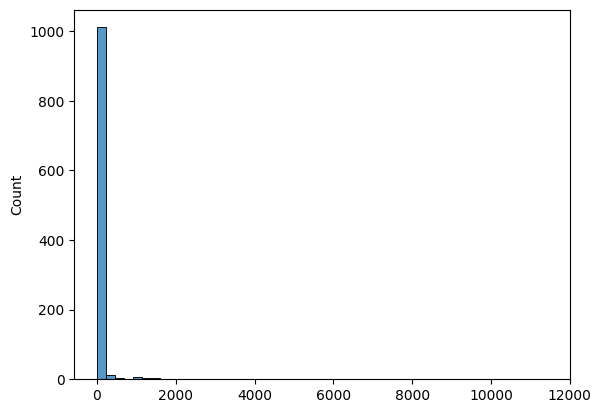

In [12]:
sns.histplot(promotion_cure_theta_after_train, bins = 50)
plt.show()

In [17]:
global_importance

array([ 7.0721006, 18.49727  ,  4.573169 , ...,  3.6008976,  4.985923 ,
        3.668553 ], shape=(3000,), dtype=float32)

In [19]:
gene_gradients.shape

(1071, 3000)

In [31]:
# Ensure your input is a TF tensor requiring gradients
X_tensor = tf.convert_to_tensor(X, dtype = tf.float32)

with tf.GradientTape() as tape:
    tape.watch(X_tensor)
    # Get the raw logit before the link function to avoid vanishing gradient artifacts in the derivative
    logits = promotion_cure_model(X_tensor) 

# Calculate gradients of the logits wrt the input genes
# Shape will be (n_patients, 3000)
gene_gradients = tape.gradient(logits, X_tensor).numpy()

# Calculate global importance: the mean absolute gradient across all patients
global_importance = np.mean( np.abs(gene_gradients), axis = 0)

# Get the column indices of the top 20 most important genes
top_20_idx = np.argsort(global_importance)[::-1][:20]
top_20_idx

array([2068,  974, 2023, 2014, 2004, 1922, 2167, 2151, 2889, 1741, 2417,
       2660, 2898, 1984,  995, 1097, 1229,  858,  831, 2878])

<Axes: ylabel='Count'>

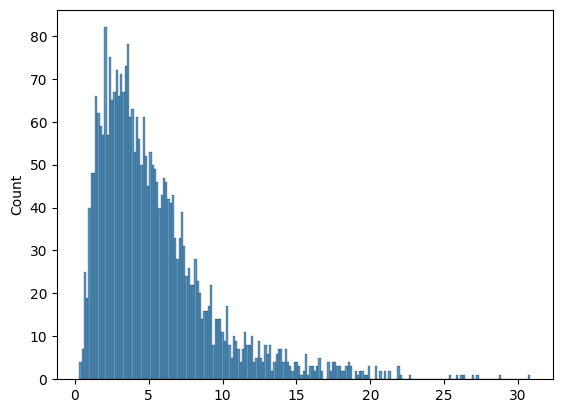

In [32]:
sns.histplot(x = global_importance, bins = 200)

In [49]:
top_20_idx

array([2068,  974, 2023, 2014, 2004, 1922, 2167, 2151, 2889, 1741, 2417,
       2660, 2898, 1984,  995, 1097, 1229,  858,  831, 2878])

In [57]:
gene_ids = df.iloc[:,2:].iloc[:,i_sort[:k_genes]].columns
print("Top 20 gene ids:\n", gene_ids[top_20_idx], sep = "")

Top 20 gene ids:
Index(['ENSG00000227403.2', 'ENSG00000069188.17', 'ENSG00000115380.20',
       'ENSG00000260573.4', 'ENSG00000186998.16', 'ENSG00000117407.17',
       'ENSG00000140323.6', 'ENSG00000267640.6', 'ENSG00000251350.2',
       'ENSG00000152467.10', 'ENSG00000079385.23', 'ENSG00000157703.16',
       'ENSG00000251129.2', 'ENSG00000148408.13', 'ENSG00000114115.10',
       'ENSG00000269416.6', 'ENSG00000140287.11', 'ENSG00000197249.14',
       'ENSG00000171004.18', 'ENSG00000273295.1'],
      dtype='object')


In [59]:
gene_metadata = pd.read_csv("gene_metadata.csv")

In [69]:
top_20_genes = gene_metadata.loc[ np.isin(gene_metadata["gene_id"], gene_ids[top_20_idx]), :]
top_20_genes

,source,type,score,phase,gene_id,gene_type,gene_name,level,hgnc_id,havana_gene
1067,HAVANA,gene,NaN,NaN,ENSG00000069188.17,protein_coding,SDK2,2,HGNC:19308,OTTHUMG00000152726.5
1462,HAVANA,gene,NaN,NaN,ENSG00000079385.23,protein_coding,CEACAM1,2,HGNC:1814,OTTHUMG00000151078.8
4255,HAVANA,gene,NaN,NaN,ENSG00000114115.10,protein_coding,RBP1,1,HGNC:9919,OTTHUMG00000155751.5
4419,HAVANA,gene,NaN,NaN,ENSG00000115380.20,protein_coding,EFEMP1,2,HGNC:3218,OTTHUMG00000129343.7
4702,HAVANA,gene,NaN,NaN,ENSG00000117407.17,protein_coding,ARTN,2,HGNC:727,OTTHUMG00000007705.4
7937,HAVANA,gene,NaN,NaN,ENSG00000140287.11,protein_coding,HDC,2,HGNC:4855,OTTHUMG00000131644.4
7943,HAVANA,gene,NaN,NaN,ENSG00000140323.6,protein_coding,DISP2,2,HGNC:19712,OTTHUMG00000129983.4
9091,HAVANA,gene,NaN,NaN,ENSG00000148408.13,protein_coding,CACNA1B,2,HGNC:1389,OTTHUMG00000021002.4
9542,HAVANA,gene,NaN,NaN,ENSG00000152467.10,protein_coding,ZSCAN1,2,HGNC:23712,OTTHUMG00000183381.2
10128,HAVANA,gene,NaN,NaN,ENSG00000157703.16,protein_coding,SVOPL,1,HGNC:27034,OTTHUMG00000155870.7


In [72]:
print(list(top_20_genes["gene_name"]))

['SDK2', 'CEACAM1', 'RBP1', 'EFEMP1', 'ARTN', 'HDC', 'DISP2', 'CACNA1B', 'ZSCAN1', 'SVOPL', 'HS6ST2', 'EMID1', 'SERPINA1', 'LINC01806', 'LINC02506', 'LINC02475', 'AC007493.1', 'AC016582.3', 'LINC01224', 'AP000350.6']


In [63]:
gene_metadata["gene_id"]

0        ENSG00000000003.15
1         ENSG00000000005.6
2        ENSG00000000419.13
3        ENSG00000000457.14
4        ENSG00000000460.17
                ...        
60655     ENSG00000288669.1
60656     ENSG00000288670.1
60657     ENSG00000288671.1
60658     ENSG00000288674.1
60659     ENSG00000288675.1
Name: gene_id, Length: 60660, dtype: object

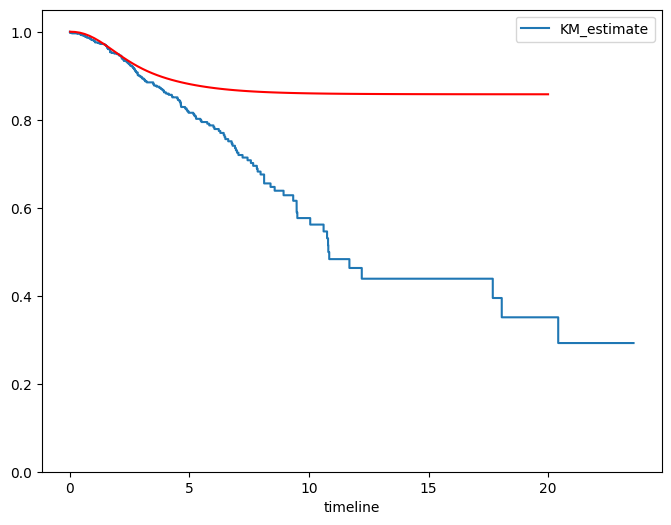

In [50]:
theta_X = promotion_cure_model.predict(X)["theta"]
lam_X = promotion_cure_model.predict("lam")
rho_X = promotion_cure_model.predict("rho")

ts = tf.constant(np.linspace(0.01, 20, 100), dtype = tf.float32)

F0 = 1 - np.exp( -(ts / lam_X)**rho_X )
S_ts = tf.math.exp( -theta_X * F0 )
S_ts_avg = tf.reduce_mean( S_ts, axis = 0 )

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df["time"]/365, df["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, censor_styles={
    'ms': 7,      # marker size
    'marker': '+', # marker shape
    'mew': 2,       # marker edge width
    'markeredgecolor': 'black',
    'zorder': 5
})
# sns.lineplot(x = ts, y = S_ts_avg, color = "red")
ax.plot(ts, S_ts_avg, color = "red")

ax.set_ylim(0,1.05)

plt.show()

<Axes: ylabel='Count'>

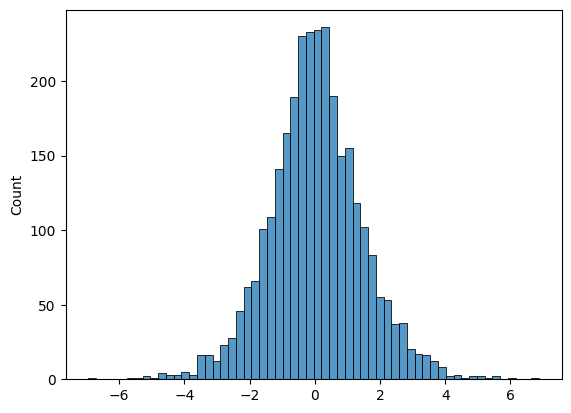

In [19]:
sns.histplot(x = np.sum( promotion_cure_model.get_weights()[2], axis = 1 ) )

In [73]:
df.iloc[:,2:].iloc[:,np.where( np.abs(np.sum( promotion_cure_model.get_weights()[2], axis = 1 )) >= 1 )[0]]

,ENSG00000000003.15,ENSG00000000457.14,ENSG00000001461.17,ENSG00000002079.14,ENSG00000004478.8,ENSG00000004766.17,ENSG00000004864.14,ENSG00000004866.22,ENSG00000004948.16,ENSG00000005001.10,...,ENSG00000105219.10,ENSG00000105221.18,ENSG00000105245.9,ENSG00000105246.6,ENSG00000105270.15,ENSG00000105325.15,ENSG00000105339.11,ENSG00000105373.19,ENSG00000105379.10,ENSG00000105393.16
0,9.236898,10.513271,11.333915,3.881094,14.477951,9.941881,9.031947,9.790783,4.444878,9.356933,...,8.977784,13.155649,10.373464,8.350586,8.522641,11.981124,10.641963,13.371833,10.262980,10.026245
1,10.223195,10.076926,9.451400,4.328494,14.754738,10.546343,11.547115,10.514061,6.547938,9.961137,...,5.851307,12.738567,10.448425,7.858453,9.149013,12.176383,9.562258,13.908272,9.284550,10.682788
2,10.449917,10.244865,10.935614,4.800738,14.494649,10.055533,10.339131,10.127746,4.408410,8.483425,...,9.449913,13.337146,10.104927,5.627876,11.153269,11.408033,9.022012,13.855502,9.301691,9.388245
3,10.943582,10.733436,10.701011,3.779970,12.738859,10.682677,9.446416,10.203443,5.161582,9.115602,...,8.729115,12.731743,9.626032,8.865444,9.823047,12.048297,10.005238,14.481684,9.704464,10.626235
4,9.740298,10.700813,11.113687,4.469670,15.002495,10.765503,11.798929,10.207732,5.845256,10.334678,...,7.102125,11.863522,9.059946,6.151388,10.137367,10.834217,9.230080,12.710821,9.259580,9.080437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,10.236238,11.239317,11.325557,3.730406,12.649205,10.504999,9.516012,10.023639,4.506498,9.530257,...,8.156124,12.779006,10.043637,7.107429,9.622899,11.711154,10.440472,14.705734,9.844285,10.575375
1090,11.437981,9.781260,10.967417,4.773952,13.848920,9.994686,10.928893,10.631355,5.134143,7.589605,...,7.852048,13.938685,11.589367,7.562356,10.513229,11.628137,10.519135,13.866168,10.092996,9.975913
1091,12.084716,10.508346,11.383820,4.489587,15.108752,11.341796,12.204547,11.293432,4.594443,7.130842,...,4.091706,13.028939,10.502489,8.727036,8.077973,10.811661,9.983670,13.527199,8.310451,10.427196
1092,11.058886,10.582066,11.591143,3.933588,12.602932,10.898937,10.170520,10.656721,5.637005,8.228138,...,7.359710,12.030201,9.596869,6.392238,10.943201,10.550034,9.772430,11.984113,7.497633,9.241409
